In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!nvidia-smi

Thu Oct 30 09:57:16 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
import importlib.util

for m in ['torchinfo', 'addict', 'yapf', 'ftfy']:
    if importlib.util.find_spec(m) is None:
        !pip install {m}

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.8 MB/s eta 0:00:00


In [4]:
import torch
import sys
import os

HOME = os.getcwd()
project_path = '/content/drive/MyDrive/PROJECT_Query2label' # change to your project path

if not project_path in sys.path:
    sys.path.append(os.path.abspath(project_path))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Device: {device}')
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    !nvidia-smi

Device: cuda
NVIDIA A100-SXM4-80GB
Thu Oct 30 09:57:42 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             55W /  400W |       5MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+------------

# **Query2label**
Pytorch Imp: https://github.com/SlongLiu/query2labels
Paper: https://arxiv.org/abs/2107.10834
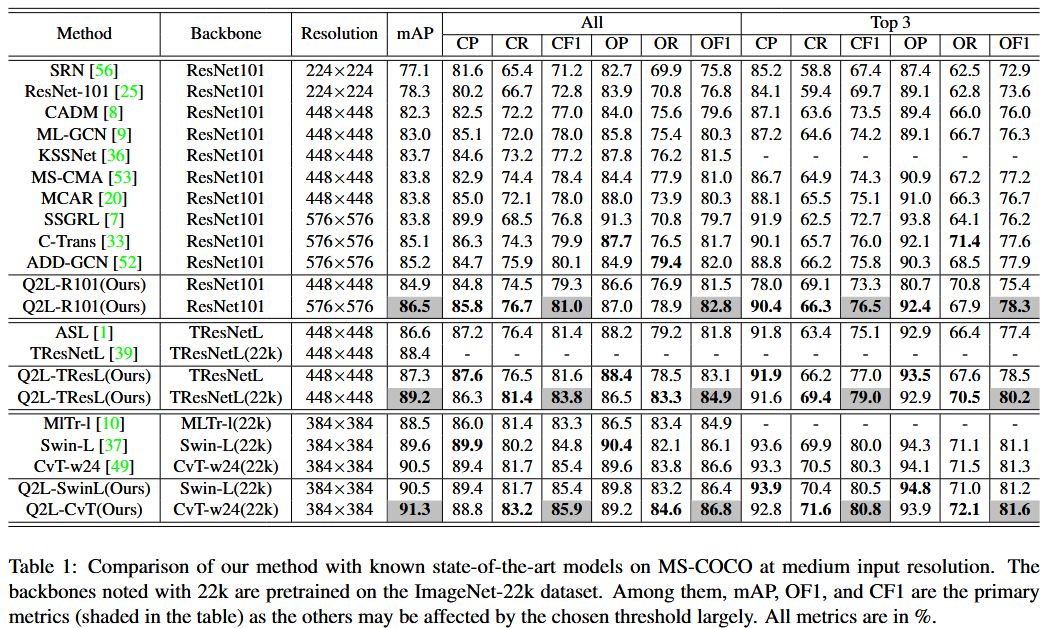
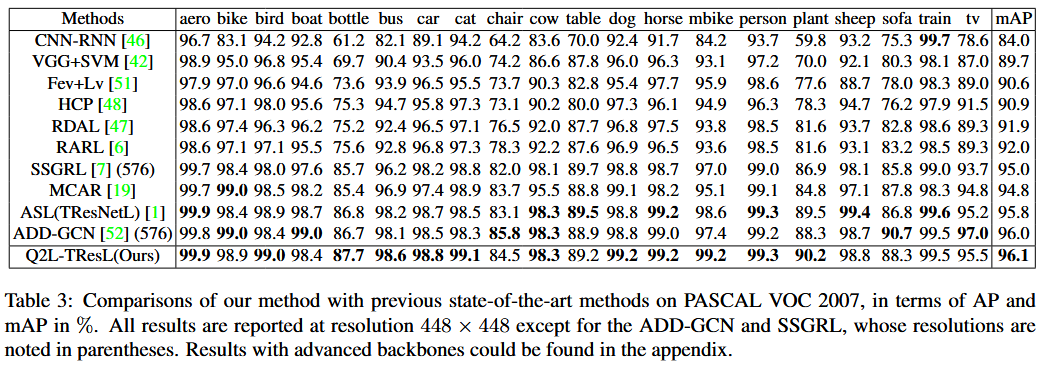
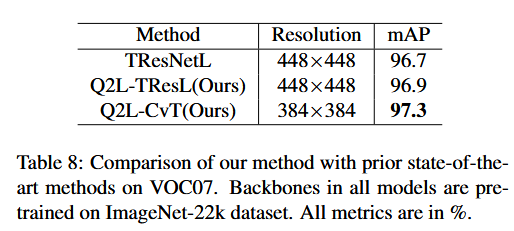

## Loss Function

In [5]:
import torch
import torch.nn as nn

class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05, eps=1e-5, disable_torch_grad_focal_loss=True, reduction='mean'):
        super(AsymmetricLoss, self).__init__()

        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.disable_torch_grad_focal_loss = disable_torch_grad_focal_loss
        self.eps = eps
        self.reduction = reduction

    def forward(self, x, y):
        """"
        Parameters
        ----------
        x: input logits
        y: targets (multi-label binarized vector)
        """

        # Calculating Probabilities
        x_sigmoid = torch.sigmoid(x)
        xs_pos = x_sigmoid
        xs_neg = 1 - x_sigmoid

        # Asymmetric Clipping
        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)

        # Basic CE calculation
        los_pos = y * torch.log(xs_pos.clamp(min=self.eps))
        los_neg = (1 - y) * torch.log(xs_neg.clamp(min=self.eps))
        loss = los_pos + los_neg

        # Asymmetric Focusing
        if self.gamma_neg > 0 or self.gamma_pos > 0:
            if self.disable_torch_grad_focal_loss:
                torch.set_grad_enabled(False)
            pt0 = xs_pos * y
            pt1 = xs_neg * (1 - y)  # pt = p if t > 0 else 1-p
            pt = pt0 + pt1
            one_sided_gamma = self.gamma_pos * y + self.gamma_neg * (1 - y)
            one_sided_w = torch.pow(1 - pt, one_sided_gamma)
            if self.disable_torch_grad_focal_loss:
                torch.set_grad_enabled(True)
            loss *= one_sided_w

        if self.reduction == 'mean':
            return -loss.mean()
        elif self.reduction == 'sum':
            return -loss.sum()
        else:
            return -loss


class AsymmetricLossOptimized(nn.Module):
    ''' Notice - optimized version, minimizes memory allocation and gpu uploading,
    favors inplace operations'''

    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05, eps=1e-5, disable_torch_grad_focal_loss=False, reduction='mean'):
        super(AsymmetricLossOptimized, self).__init__()

        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.disable_torch_grad_focal_loss = disable_torch_grad_focal_loss
        self.eps = eps
        self.reduction = reduction

        # prevent memory allocation and gpu uploading every iteration, and encourages inplace operations
        self.targets = self.anti_targets = self.xs_pos = self.xs_neg = self.asymmetric_w = self.loss = None

    def forward(self, x, y):
        """"
        Parameters
        ----------
        x: input logits
        y: targets (multi-label binarized vector)
        """

        self.targets = y
        self.anti_targets = 1 - y

        # Calculating Probabilities
        self.xs_pos = torch.sigmoid(x)
        self.xs_neg = 1.0 - self.xs_pos

        # Asymmetric Clipping
        if self.clip is not None and self.clip > 0:
            self.xs_neg.add_(self.clip).clamp_(max=1)

        # Basic CE calculation
        loss = self.targets * torch.log(self.xs_pos.clamp(min=self.eps))
        loss.add_(self.anti_targets * torch.log(self.xs_neg.clamp(min=self.eps)))

        # Asymmetric Focusing
        if self.gamma_neg > 0 or self.gamma_pos > 0:
            if self.disable_torch_grad_focal_loss:
                with torch.no_grad():
                    # if self.disable_torch_grad_focal_loss:
                    #     torch.set_grad_enabled(False)
                    self.xs_pos = self.xs_pos * self.targets
                    self.xs_neg = self.xs_neg * self.anti_targets
                    self.asymmetric_w = torch.pow(1 - self.xs_pos - self.xs_neg,
                                                  self.gamma_pos * self.targets + self.gamma_neg * self.anti_targets)
                    # if self.disable_torch_grad_focal_loss:
                    #     torch.set_grad_enabled(True)
                    loss *= self.asymmetric_w
            else:
                self.xs_pos = self.xs_pos * self.targets
                self.xs_neg = self.xs_neg * self.anti_targets
                self.asymmetric_w = torch.pow(1 - self.xs_pos - self.xs_neg,
                                            self.gamma_pos * self.targets + self.gamma_neg * self.anti_targets)
                loss *= self.asymmetric_w

        if self.reduction == 'mean':
            return -loss.mean()
        elif self.reduction == 'sum':
            _loss = -loss.sum() / x.size(0)
            _loss = _loss / y.size(1) * 1000
            return _loss
        else:
            return -loss

## GCN Layer

In [6]:
import math
import numpy as np
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Parameter

class GraphConvolution(nn.Module):
    """
    Simple GCN layer, similar to https://arxiv.org/abs/1609.02907
    """

    def __init__(self, in_features, out_features, epsilon=0.7, bias=False, use_phat=False, phat_norm=True):
        super(GraphConvolution, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.epsilon = epsilon
        self.use_phat = use_phat
        self.phat_norm = phat_norm
        self.weight = Parameter(torch.Tensor(in_features, out_features))

        if self.use_phat:
            self.S = torch.from_numpy(np.asarray( # Semantic Matrix (ConceptNet)
                json.load(open(os.path.join(project_path, 'data/topology', 'CM_kg_55_info.json'), 'r'))[f'KG_{"".join(filter(str.isalpha, self.dataname))}_info']['S']
            )).float()
            self.S = self.S[~torch.all(self.S == 0, dim=1)]
            self.S = self.S[:, ~torch.all(self.S == 0, dim=0)]

        if bias:
            self.bias = Parameter(torch.Tensor(1, 1, out_features))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.weight.size(1))
        self.weight.data.uniform_(-stdv, stdv)
        if self.bias is not None:
            self.bias.data.uniform_(-stdv, stdv)

    def find_p_hat(self, x, S, lk=4, num_iterations=10, epsilon=0.7, use_norm=False):
        """
        Compute the knowledge aware features, based on the GCN's output and semantic consistency.
        Reference: https://github.com/tue-mps/rescience-ijcai2017-230.
        :param x: tensor of GCN's output
        :param S: semantic consistency matrix
        :param lk: number of largest semantic consistent classes to consider for p_hat
        :param num_iterations: number of iterations to calculate p_hat
        :param epsilon: trade-off parameter for traditional detections and knowledge aware detections
        :return p_hat: tensor of knowledge aware features
        """
        x = x.T
        C, N = x.shape
        S = S.to(device)

        if N == 1:
            return x.T

        topk_vals, topk_inds = torch.topk(S, lk, dim=1)
        S_highest = torch.zeros_like(S, dtype=torch.float, device=device)
        S_highest.scatter_(1, topk_inds, topk_vals)
        S_highest = S_highest / (S_highest.sum(dim=1, keepdim=True) + 1e-6)

        p_hat = torch.full(size=(C, N), fill_value=(1 / N), dtype=torch.float, device=device)
        for _ in range(num_iterations):
            num = torch.matmul(p_hat, S_highest.T)
            denom = S_highest.sum(dim=1, keepdim=True).T + 1e-6
            p_hat = (1 - epsilon) * (num / denom) + epsilon * x
            if use_norm:
                p_hat = F.normalize(p_hat, p=1, dim=1)

        return p_hat.T

    def forward(self, input, adj):
        support = torch.matmul(input, self.weight) # (N, C_out)
        output = torch.matmul(adj, support) # (N, C_out)

        if self.use_phat:
            output = self.find_p_hat(output, self.S, epsilon=self.epsilon, use_norm=self.phat_norm)

        if self.bias is not None:
            return output + self.bias
        else:
            return output

    def __repr__(self):
        return self.__class__.__name__ + ' (' \
               + str(self.in_features) + ' -> ' \
               + str(self.out_features) + ')'


## GAT Layer

In [7]:
import numpy as np
import json
import torch
import torch.nn as nn
import torch.nn.functional as F

class GATLayer(nn.Module):
    """
    Base class for all implementations as there is much code that would otherwise be copy/pasted.

    """

    def __init__(self, in_feats, out_feats, num_of_heads, concat=True, activation=nn.ELU(),
                 dropout_prob=0.6, add_skip_connection=True, bias=True, log_attention_weights=False):

        super(GATLayer, self).__init__()

        self.num_of_heads = num_of_heads
        self.out_feats = out_feats
        self.concat = concat  # whether we should concatenate or average the attention heads
        self.add_skip_connection = add_skip_connection

        #
        # Trainable weights: linear projection matrix (denoted as "W" in the paper), attention target/source
        # (denoted as "a" in the paper) and bias (not mentioned in the paper but present in the official GAT repo)
        #

        self.linear_proj = nn.Linear(in_feats, num_of_heads * out_feats, bias=False)

        # After we concatenate target node (node i) and source node (node j) we apply the additive scoring function
        # which gives us un-normalized score "e". Here we split the "a" vector - but the semantics remain the same.

        # Basically instead of doing [x, y] (concatenation, x/y are node feature vectors) and dot product with "a"
        # we instead do a dot product between x and "a_left" and y and "a_right" and we sum them up
        self.scoring_fn_target = nn.Parameter(torch.Tensor(1, num_of_heads, out_feats))
        self.scoring_fn_source = nn.Parameter(torch.Tensor(1, num_of_heads, out_feats))

        if bias and concat:
            self.bias = nn.Parameter(torch.Tensor(num_of_heads * out_feats))
        elif bias and not concat:
            self.bias = nn.Parameter(torch.Tensor(out_feats))
        else:
            self.register_parameter('bias', None)

        if add_skip_connection:
            self.skip_proj = nn.Linear(in_feats, num_of_heads * out_feats, bias=False)
        else:
            self.register_parameter('skip_proj', None)

        #
        # End of trainable weights
        #

        self.leakyReLU = nn.LeakyReLU(0.2)
        self.softmax = nn.Softmax(dim=-1)
        self.activation = activation
        self.dropout = nn.Dropout(p=dropout_prob)

        self.log_attention_weights = log_attention_weights  # whether we should log the attention weights
        self.attention_weights = None  # for later visualization purposes, I cache the weights here

        self.init_params()

    def init_params(self):
        """
        The reason we're using Glorot (aka Xavier uniform) initialization is because it's a default TF initialization:
            https://stackoverflow.com/questions/37350131/what-is-the-default-variable-initializer-in-tensorflow

        The original repo was developed in TensorFlow (TF) and they used the default initialization.
        Feel free to experiment - there may be better initializations depending on your problem.

        """
        nn.init.xavier_uniform_(self.linear_proj.weight)
        nn.init.xavier_uniform_(self.scoring_fn_target)
        nn.init.xavier_uniform_(self.scoring_fn_source)

        if self.bias is not None:
            torch.nn.init.zeros_(self.bias)

    def skip_concat_bias(self, attention_coefficients, in_node_feats, out_node_feats):
        if self.log_attention_weights:
            self.attention_weights = attention_coefficients

        # if the tensor is not contiguously stored in memory we'll get an error after we try to do certain ops like view
        if not out_node_feats.is_contiguous():
            out_node_feats = out_node_feats.contiguous()

        if self.add_skip_connection:  # add skip or residual connection
            if out_node_feats.shape[-1] == in_node_feats.shape[-1]:  # if C_in == C_out
                # unsqueeze does this: (N, C_in) -> (N, 1, C_in), out features are (N, NH, C_out) so 1 gets broadcast to NH
                out_node_feats += in_node_feats.unsqueeze(1)
            else:
                # C_in != C_out so we need to project input feature vectors into dimension that can be added to output
                # feature vectors. skip_proj adds lots of additional capacity which may cause overfitting.
                out_node_feats += self.skip_proj(in_node_feats).view(-1, self.num_of_heads, self.out_feats)

        if self.concat:
            # shape = (N, NH, C_out) -> (N, NH*C_out)
            out_node_feats = out_node_feats.view(-1, self.num_of_heads * self.out_feats)
        else:
            # shape = (N, NH, C_out) -> (N, C_out)
            out_node_feats = out_node_feats.mean(dim=1) # head dim=1

        if self.bias is not None:
            out_node_feats += self.bias

        return out_node_feats if self.activation is None else self.activation(out_node_feats)

    def forward(self, x, connectivity_mask):
        """
        This implementation was inspired by the official GAT implementation: https://github.com/PetarV-/GAT
        """

        #
        # Step 1: Linear Projection + regularization (using linear layer instead of matmul as in imp1)
        #

        N = x.shape[0]
        assert connectivity_mask.shape == (N, N), \
            f'Expected connectivity matrix with shape=({N},{N}), got shape={connectivity_mask.shape}.'

        # shape = (N, C_in) where N - number of nodes in the graph, C_in - number of input features per node
        x = self.dropout(x)

        # shape = (N, C_in) * (C_in, NH*C_out) -> (N, NH, C_out) where NH - number of heads, C_out - num of output features
        # We project the input node features into NH independent output features (one for each attention head)
        x_proj = self.linear_proj(x).view(-1, self.num_of_heads, self.out_feats)

        x_proj = self.dropout(x_proj)

        #
        # Step 2: Edge attention calculation
        #

        # Apply the scoring function (* represents element-wise (a.k.a. Hadamard) product)
        # shape = (N, NH, C_out) * (1, NH, C_out) -> (N, NH, 1)
        scores_source = torch.sum((x_proj * self.scoring_fn_source), dim=-1, keepdim=True)
        scores_target = torch.sum((x_proj * self.scoring_fn_target), dim=-1, keepdim=True)

        # src shape = (NH, N, 1) and trg shape = (NH, 1, N)
        scores_source = scores_source.transpose(0, 1)
        scores_target = scores_target.permute(1, 2, 0)

        # shape = (NH, N, 1) + (NH, 1, N) -> (NH, N, N) with the magic of automatic broadcast <3
        all_scores = self.leakyReLU(scores_source + scores_target)
        all_attention_coefficients = self.softmax(all_scores + connectivity_mask)

        #
        # Step 3: Neighborhood aggregation
        #

        # batch matrix multiply, shape = (NH, N, N) * (NH, N, C_out) -> (NH, N, C_out)
        out = torch.bmm(all_attention_coefficients, x_proj.transpose(0, 1))

        # shape = (N, NH, C_out)
        out = out.permute(1, 0, 2)

        #
        # Step 4: Residual/skip connections, concat and bias
        #

        out = self.skip_concat_bias(all_attention_coefficients, x, out)
        return out


class GAT(nn.Module):
    def __init__(self, num_of_layers, num_heads_per_layer, num_features_per_layer, # (in_feats, hid_feats, out_feats)
                 add_skip_connection=True, bias=True, dropout=0.6, use_phat=False,
                 phat_norm=False, log_attention_weights=False, dataname=None): # Add dataname here

        super(GAT, self).__init__()
        assert num_of_layers == len(num_heads_per_layer) == len(num_features_per_layer) - 1, f'Enter valid arch params.'

        self.GATLayer = GATLayer
        self.use_phat = use_phat
        self.phat_norm = phat_norm
        num_heads_per_layer = [1] + num_heads_per_layer

        gat_layers = []  # collect GAT layers
        for i in range(num_of_layers):
            layer = self.GATLayer(
                in_feats=num_features_per_layer[i] * num_heads_per_layer[i],  # consequence of concatenation
                out_feats=num_features_per_layer[i+1],
                num_of_heads=num_heads_per_layer[i+1],
                concat=True if i < num_of_layers - 1 else False,  # last GAT layer does mean avg, the others do concat
                activation=nn.LeakyReLU(0.2) if i < num_of_layers - 1 else None,  # last layer just outputs raw scores
                dropout_prob=dropout,
                add_skip_connection=add_skip_connection,
                bias=bias,
                log_attention_weights=log_attention_weights
            )
            gat_layers.append(layer)

        self.gat_net = nn.ModuleList([
            *gat_layers,
        ])

        # Semantic Matrix (ConceptNet)
        S_file = os.path.join(project_path, 'data/topology', 'CM_kg_55_info.json')
        _S = np.asarray(
            json.load(open(S_file, 'r'))[f'KG_{"".join(filter(str.isalpha, dataname))}_info']['S'] # Use passed dataname
        )
        # Remove rows/columns if all the values are 0 comment for voc 20
        _S = _S[~np.all(_S == 0, axis=1)]
        _S = _S[:, ~np.all(_S == 0, axis=0)]
        self.S = torch.from_numpy(_S).float()

    def find_p_hat(self, x, S, lk=5, num_iterations=10, epsilon=0.7, use_norm=True):
        """
        Compute the knowledge aware features, based on the GCN's output and semantic consistency.
        Reference: https://github.com/tue-mps/rescience-ijcai2017-230.
        :param x: tensor of GCN's output
        :param S: semantic consistency matrix
        :param lk: number of largest semantic consistent classes to consider for p_hat
        :param num_iterations: number of iterations to calculate p_hat
        :param epsilon: trade-off parameter for traditional detections and knowledge aware detections
        :return p_hat: tensor of knowledge aware features
        """
        x = x.T
        C, N = x.shape
        S = S.to(device)

        if N == 1:
            return x.T

        topk_vals, topk_inds = torch.topk(S, lk, dim=1)
        S_highest = torch.zeros_like(S, dtype=torch.float, device=device)
        S_highest.scatter_(1, topk_inds, topk_vals)
        S_highest = S_highest / (S_highest.sum(dim=1, keepdim=True) + 1e-6)

        p_hat = torch.full(size=(C, N), fill_value=(1 / N), dtype=torch.float, device=device)
        for _ in range(num_iterations):
            num = torch.matmul(p_hat, S_highest.T)
            denom = S_highest.sum(dim=1, keepdim=True).T + 1e-6
            p_hat = (1 - epsilon) * (num / denom) + epsilon * x
            if use_norm:
                p_hat = F.normalize(p_hat, p=1, dim=1)

        return p_hat.T


    def forward(self, x, data):
        # Data shape: (num_nodes, num_classes)
        # print(x.shape, data.shape)
        for layer in self.gat_net:
            x = layer(x, data)
            if self.use_phat:
                x = self.find_p_hat(x, self.S, lk=5, epsilon=0.7, use_norm=self.phat_norm)
        return x

## Thresholding

In [8]:
def gen_A(num_classes, t, adj_file):
    result = pickle.load(open(adj_file, 'rb'))
    _adj = result['adj'] # label co-occurrence
    _nums = result['nums'] # label occurrence
    _nums = _nums[:, np.newaxis]
    _adj = _adj / _nums

    # thresholding (A)
    _adj[_adj < t] = 0
    _adj[_adj >= t] = 1

    # re-weighting (A')
    _adj = _adj * 0.25 / (_adj.sum(0, keepdims=True) + 1e-6)
    _adj = _adj + np.identity(num_classes, np.float32)
    return _adj

def gen_A2(num_classes, t, adj_file, S_file):
    result = pickle.load(open(adj_file, 'rb'))
    _adj = result['adj'] # label co-occurrence
    _nums = result['nums'] # label occurrence
    _nums = _nums[:, np.newaxis]
    _adj = _adj / _nums

    _S = np.asarray( # Semantic Matrix (ConceptNet)
        json.load(open(S_file, 'r'))['KG_COCO_info']['S']
    )
    _S = _S[~np.all(_S == 0, axis=1)]
    _S = _S[:, ~np.all(_S == 0, axis=0)]
    np.fill_diagonal(_S, 0)

    new_adj = np.maximum(_adj, _S)
    # new_adj = (new_adj - new_adj.min()) / (new_adj.max() - new_adj.min() + 1e-6)

    # thresholding (A)
    new_adj[new_adj < t] = 0
    new_adj[new_adj >= t] = 1

    # re-weighting (A')
    new_adj = new_adj * 0.25 / (new_adj.sum(0, keepdims=True) + 1e-6)
    new_adj = new_adj + np.identity(num_classes, np.float32)

    return new_adj

def gen_S(num_classes, t, S_file):
    _S = np.asarray( # Semantic Matrix (ConceptNet)
        json.load(open(S_file, 'r'))['KG_COCO_info']['S']
    )
    _S = _S[~np.all(_S == 0, axis=1)]
    _S = _S[:, ~np.all(_S == 0, axis=0)]

    np.fill_diagonal(_S, 0)
    S_norm = (_S - _S.min()) / (_S.max() - _S.min() + 1e-6)

    # thresholding (A)
    S_norm[S_norm < t] = 0
    S_norm[S_norm >= t] = 1

    # re-weighting (A')
    S_norm = S_norm * 0.25 / (S_norm.sum(0, keepdims=True) + 1e-6)
    S_norm = S_norm + np.identity(num_classes, np.float32)

    return S_norm

# Normalization adj
def gen_adj(A):
    D = torch.pow(A.sum(1).float(), -0.5)
    D = torch.diag(D)
    adj = torch.matmul(torch.matmul(A, D).t(), D)
    return adj

## Model

In [ ]:
import os, sys
import pickle

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributed as dist
import numpy as np
import math

from models.backbone import build_backbone
from models.transformer import build_transformer
from utils.misc import clean_state_dict

class SE_Block(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SE_Block, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        B, N, C = x.shape
        y = x.mean(dim=1) # (B, C)
        y = self.fc(y).unsqueeze(1) # (B, 1, C)
        out = x * y # (B, N, C)
        return out.squeeze(0)


class GatedFusion1D(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(GatedFusion1D, self).__init__()

        self.gate_conv = nn.Sequential(
            nn.BatchNorm1d(in_channels * 2),
            nn.Conv1d(in_channels * 2, in_channels, 1),
            nn.ReLU(inplace=True),
            nn.Conv1d(in_channels, 1, 1),
            nn.BatchNorm1d(1),
            nn.Sigmoid()
        )

    def forward(self, x1, x2):
        """
        GCF module, reference: https://github.com/ShiHanQ/GFANet.
        """
        # (B, C, N)
        x1 = x1.permute(0, 2, 1)
        x2 = x2.unsqueeze(0).permute(0, 2, 1)
        x2 = x2.expand(x1.size(0), -1, -1)

        fusion_input = torch.cat([x1, x2], dim=1) # (B, C*2, N)
        gate = self.gate_conv(fusion_input) # (B, 1, N)

        gated_output = gate * x1 + (1 - gate) * x2 # (B, C, N)
        return gated_output.permute(0, 2, 1)


class GroupWiseLinear(nn.Module):
    # could be changed to:
    # output = torch.einsum('ijk,zjk->ij', x, self.W)
    # or output = torch.einsum('ijk,jk->ij', x, self.W[0])
    def __init__(self, num_class, hidden_dim, bias=True):
        super().__init__()
        self.num_class = num_class
        self.hidden_dim = hidden_dim
        self.bias = bias

        self.W = nn.Parameter(torch.Tensor(1, num_class, hidden_dim))
        if bias:
            self.b = nn.Parameter(torch.Tensor(1, num_class))
        self.reset_parameters()

    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.W.size(2))
        for i in range(self.num_class):
            self.W[0][i].data.uniform_(-stdv, stdv)
        if self.bias:
            for i in range(self.num_class):
                self.b[0][i].data.uniform_(-stdv, stdv)

    def forward(self, x):
        # x: B,K,d
        x = (self.W * x).sum(-1)
        if self.bias:
            x = x + self.b
        return x


In [ ]:
class Qeruy2Label(nn.Module):
    def __init__(self, args, backbone, transfomer, num_class, classnames):
        """[summary]

        Args:
            backbone ([type]): backbone model.
            transfomer ([type]): transformer model.
            num_class ([type]): number of classes. (80 for MSCOCO).
        """
        super().__init__()
        self.args = args
        self.backbone = backbone
        self.transformer = transfomer
        self.num_class = num_class
        self.hidden_dim = transfomer.d_model
        self.input_proj = nn.Conv2d(backbone.num_channels, self.hidden_dim, kernel_size=1)
        self.query_embed = nn.Embedding(num_class, self.hidden_dim)

        try:
            inp = torch.from_numpy(pickle.load(open(args.input_path, 'rb'))).float() # Embedding
        except:
            inp = pickle.load(open(args.input_path, 'rb')).float()

        _adj = gen_A(num_class, 0.1, args.adj_path)
        adj = gen_adj(torch.from_numpy(_adj).float())

        self.register_buffer('inp', inp)
        self.register_buffer('adj', adj)

        if self.args.graph_type == 'GCN':
            self.gcn1 = GraphConvolution(300, 1024, use_phat=self.args.use_phat, phat_norm=self.args.phat_norm, dataname=args.dataname)
            self.gcn2 = GraphConvolution(1024, 2048, use_phat=self.args.use_phat, phat_norm=self.args.phat_norm, dataname=args.dataname)
            self.relu = nn.LeakyReLU(0.2)
        elif self.args.graph_type == 'GAT':
            self.gat = GAT(
                num_of_layers=2,
                num_heads_per_layer=[8, 1],
                num_features_per_layer=[300, 128, 2048],
                add_skip_connection=True,
                bias=False,
                dropout=0.2,
                use_phat=self.args.use_phat,
                phat_norm=self.args.phat_norm,
                dataname=args.dataname,
            )

        # self.se = SE_Block(self.hidden_dim)
        # self.gated_fusion = GatedFusion1D(self.hidden_dim, num_class)
        #self.proj = nn.Linear(self.hidden_dim * 2, self.hidden_dim)
        self.fc = GroupWiseLinear(num_class, self.hidden_dim, bias=True)

    def forward(self, input):
        src, pos = self.backbone(input)
        src, pos = src[-1], pos[-1]

        base_embed = self.query_embed.weight
        if self.args.graph_type == 'GCN':
            embed = self.gcn1(self.inp, self.adj)
            embed = self.relu(embed)
            embed = self.gcn2(embed, self.adj)
        elif self.args.graph_type == 'GAT':
            embed = self.gat(self.inp, self.adj)
        else:
            embed = torch.zeros_like(base_embed)

        # Default
        # query_input = base_embed

        # ADD + / MULT *
        query_input = base_embed + embed

        # Gated Fusion
        # query_input = self.gated_fusion(base_embed, embed)
        # query_input = self.se(query_input)

        # CAT
        #query_input = torch.cat([base_embed, embed], dim=-1)
        #query_input = self.proj(query_input)

        hs = self.transformer(src, query_input, pos)[0] # (B, N, C)
        out = self.fc(hs[-1]) # (B, N)
        return out

    def finetune_paras(self):
        from itertools import chain
        return chain(self.transformer.parameters(), self.fc.parameters(), self.input_proj.parameters(), self.query_embed.parameters())

    def load_backbone(self, path):
        print("=> loading checkpoint '{}'".format(path))
        checkpoint = torch.load(path, map_location=torch.device(dist.get_rank()))
        # import ipdb; ipdb.set_trace()
        self.backbone[0].body.load_state_dict(clean_state_dict(checkpoint['state_dict']), strict=False)
        print("=> loaded checkpoint '{}' (epoch {})"
                  .format(path, checkpoint['epoch']))


def build_q2l(args, classnames):
    backbone = build_backbone(args)
    transformer = build_transformer(args)

    model = Qeruy2Label(
        args,
        backbone = backbone,
        transfomer = transformer,
        num_class = args.num_class,
        classnames = classnames,
    )

    if not args.keep_input_proj:
        model.input_proj = nn.Identity()
        print("set model.input_proj to Indentify!")

    return model

## Trainer

In [ ]:
import math
import os, sys
import datetime
import time
from typing import List
import numpy as np
from copy import deepcopy

import torch
import torch.nn as nn
from torch.optim import lr_scheduler
import torch.distributed as dist
from torchinfo import summary

from torch.utils.tensorboard import SummaryWriter
from utils.metric import voc_mAP
from utils.misc import clean_state_dict
from utils.partial_asymmetric_loss import PartialSelectiveLoss, ComputePrior

def main_worker(args, model, train_loader, train_sampler, val_loader, logger):
    global best_mAP

    # model
    model = model.cuda()
    ema_m = ModelEma(model, args.ema_decay) # 0.9997
    if args.loss_name == 'CSL' and args.use_prior:
        prior = ComputePrior(val_loader.dataset.category_names, args.output)
        args.prior_path = os.path.join(args.output, "train_avg_preds.csv")
    model = torch.nn.parallel.DistributedDataParallel(model, device_ids=[args.local_rank], broadcast_buffers=False, find_unused_parameters=True)

    logger.info(
        summary(model.module, input_size=(args.batch_size, 3, args.img_size, args.img_size)))

    # criterion
    if args.loss_name == 'ASL':
        criterion = AsymmetricLossOptimized(
            gamma_neg=args.gamma_neg, gamma_pos=args.gamma_pos,
            clip=args.loss_clip,
            disable_torch_grad_focal_loss=args.dtgfl,
            eps=args.eps,
            reduction='sum'
        )
    elif args.loss_name == 'CSL':
        criterion = PartialSelectiveLoss(args)

    # optimizer
    args.lr_mult = args.batch_size / 256
    if args.optim == 'AdamW':
        param_dicts = [
            {"params": [p for n, p in model.module.named_parameters() if p.requires_grad]},
        ]
        optimizer = getattr(torch.optim, args.optim)(
            param_dicts,
            args.lr_mult * args.lr,
            betas=(0.9, 0.999), eps=1e-08, weight_decay=args.weight_decay
        )
    elif args.optim == 'Adam_twd':
        parameters = add_weight_decay(model, args.weight_decay)
        optimizer = torch.optim.Adam(
            parameters,
            args.lr_mult * args.lr,
            betas=(0.9, 0.999), eps=1e-08, weight_decay=0
        )
    else:
        raise NotImplementedError

    # tensorboard
    if dist.get_rank() == 0:
        summary_writer = SummaryWriter(log_dir=args.output)
    else:
        summary_writer = None

    # optionally resume from a checkpoint
    if args.resume:
        if os.path.isfile(args.resume):
            logger.info("=> loading checkpoint '{}'".format(args.resume))
            checkpoint = torch.load(args.resume, map_location=torch.device(dist.get_rank()), weights_only=False)

            if 'state_dict' in checkpoint:
                state_dict = clean_state_dict(checkpoint['state_dict'])
            elif 'model' in checkpoint:
                state_dict = clean_state_dict(checkpoint['model'])
            else:
                raise ValueError("No model or state_dicr Found!!!")
            logger.info("Omitting {}".format(args.resume_omit))
            # import ipdb; ipdb.set_trace()
            for omit_name in args.resume_omit:
                del state_dict[omit_name]
            model.module.load_state_dict(state_dict, strict=False)
            # model.module.load_state_dict(checkpoint['state_dict'])
            # logger.info("=> loaded checkpoint '{}' (epoch {})"
            #       .format(args.resume, checkpoint['epoch']))
            del checkpoint
            del state_dict
            torch.cuda.empty_cache()
        else:
            logger.info("=> no checkpoint found at '{}'".format(args.resume))

    if args.evaluate:
        _, mAP = validate(val_loader, model, criterion, args, logger)
        logger.info(' * mAP {mAP:.5f}'
              .format(mAP=mAP))
        return

    epoch_time = AverageMeterHMS('TT')
    eta = AverageMeterHMS('ETA', val_only=True)
    losses = AverageMeter('Loss', ':5.3f', val_only=True)
    losses_ema = AverageMeter('Loss_ema', ':5.3f', val_only=True)
    mAPs = AverageMeter('mAP', ':5.5f', val_only=True)
    mAPs_ema = AverageMeter('mAP_ema', ':5.5f', val_only=True)
    progress = ProgressMeter(
        args.epochs - 1,
        [eta, epoch_time, losses, mAPs, losses_ema, mAPs_ema],
        prefix='=> Test Epoch: ')

    # one cycle learning rate
    scheduler = lr_scheduler.OneCycleLR(optimizer,
                                        max_lr=args.lr,
                                        steps_per_epoch=len(train_loader),
                                        epochs=args.epochs,
                                        pct_start=0.2)
    # scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

    end = time.time()
    best_epoch = -1
    best_regular_mAP = 0
    best_regular_epoch = -1
    best_ema_mAP = 0
    regular_mAP_list = []
    ema_mAP_list = []
    torch.cuda.empty_cache()
    for epoch in range(args.start_epoch, args.epochs):
        train_sampler.set_epoch(epoch)
        if args.ema_epoch == epoch:
            ema_m = ModelEma(model.module, args.ema_decay)
            torch.cuda.empty_cache()
        torch.cuda.empty_cache()

        # train for one epoch
        loss = train(train_loader, model, ema_m, prior if (args.loss_name == 'CSL' and args.use_prior) else None,
                     criterion, optimizer, scheduler, epoch, args, logger)

        if summary_writer:
            # tensorboard logger
            summary_writer.add_scalar('train_loss', loss, epoch)
            # summary_writer.add_scalar('train_acc1', acc1, epoch)
            summary_writer.add_scalar('learning_rate', optimizer.param_groups[0]['lr'], epoch)

        if epoch % args.val_interval == 0:

            # evaluate on validation set
            loss, mAP = validate(val_loader, model, criterion, args, logger, 'reg')
            loss_ema, mAP_ema = validate(val_loader, ema_m.module, criterion, args, logger, 'ema')
            losses.update(loss)
            mAPs.update(mAP)
            losses_ema.update(loss_ema)
            mAPs_ema.update(mAP_ema)
            epoch_time.update(time.time() - end)
            end = time.time()
            eta.update(epoch_time.avg * (args.epochs - epoch - 1))

            regular_mAP_list.append(mAP)
            ema_mAP_list.append(mAP_ema)

            progress.display(epoch, logger)

            if summary_writer:
                # tensorboard logger
                summary_writer.add_scalar('val_loss', loss, epoch)
                summary_writer.add_scalar('val_mAP', mAP, epoch)
                summary_writer.add_scalar('val_loss_ema', loss_ema, epoch)
                summary_writer.add_scalar('val_mAP_ema', mAP_ema, epoch)

            # remember best (regular) mAP and corresponding epochs
            if mAP > best_regular_mAP:
                best_regular_mAP = max(best_regular_mAP, mAP)
                best_regular_epoch = epoch
            if mAP_ema > best_ema_mAP:
                best_ema_mAP = max(mAP_ema, best_ema_mAP)

            if mAP_ema > mAP:
                mAP = mAP_ema
                state_dict = ema_m.module.state_dict()
            else:
                state_dict = model.state_dict()

            # scheduler.step(mAP)
            is_best = mAP > best_mAP
            if is_best:
                best_epoch = epoch
            best_mAP = max(mAP, best_mAP)

            logger.info("{} | Set best mAP {} in ep {}".format(epoch, best_mAP, best_epoch))
            logger.info("   | best regular mAP {} in ep {}".format(best_regular_mAP, best_regular_epoch))

            if dist.get_rank() == 0:
                save_checkpoint({
                    'epoch': epoch + 1,
                    'arch': args.arch,
                    'state_dict': state_dict,
                    'best_mAP': best_mAP,
                    'optimizer' : optimizer.state_dict(),
                }, is_best=is_best, path=args.output)
            # filename=os.path.join(args.output, 'checkpoint_{:04d}.pth.tar'.format(epoch))

            if math.isnan(loss) or math.isnan(loss_ema):
                save_checkpoint({
                    'epoch': epoch + 1,
                    'arch': args.arch,
                    'state_dict': model.state_dict(),
                    'best_mAP': best_mAP,
                    'optimizer' : optimizer.state_dict(),
                }, is_best=is_best, path=args.output, nan=True)
                logger.info('Loss is NaN, break')
                sys.exit(1)


            # early stop
            if args.early_stop:
                if best_epoch >= 0 and epoch - max(best_epoch, best_regular_epoch) > 5:
                    if len(ema_mAP_list) > 1 and ema_mAP_list[-1] < best_ema_mAP:
                        logger.info("epoch - best_epoch = {}, stop!".format(epoch - best_epoch))
                        if dist.get_rank() == 0 and args.kill_stop:
                            filename = sys.argv[0].split(' ')[0].strip()
                            killedlist = kill_process(filename, os.getpid())
                            logger.info("Kill all process of {}: ".format(filename) + " ".join(killedlist))
                        break

    print("Best mAP:", best_mAP)

    if summary_writer:
        summary_writer.close()

    return 0

def gradient_centralization(optimizer):
    """Apply gradient centralization to the optimizer"""
    for group in optimizer.param_groups:
        for p in group['params']:
            if p.grad is not None and len(p.grad.shape) > 1:
                # Center gradients for parameters with more than 1 dimension
                grad = p.grad.data
                grad.sub_(grad.mean(dim=tuple(range(1, len(grad.shape))), keepdim=True))

def train(train_loader, model, ema_m, prior, criterion, optimizer, scheduler, epoch, args, logger):
    scaler = torch.amp.GradScaler(device=device.type, enabled=args.amp)

    batch_time = AverageMeter('T', ':5.3f')
    data_time = AverageMeter('DT', ':5.3f')
    speed_gpu = AverageMeter('S1', ':.1f')
    speed_all = AverageMeter('SA', ':.1f')
    losses = AverageMeter('Loss', ':5.3f')
    lr = AverageMeter('LR', ':.3e', val_only=True)
    mem = AverageMeter('Mem', ':.0f', val_only=True)
    progress = ProgressMeter(
        len(train_loader),
        [batch_time, data_time, speed_gpu, speed_all, lr, losses, mem],
        prefix="Epoch: [{}/{}]".format(epoch, args.epochs - 1))

    def get_learning_rate(optimizer):
        for param_group in optimizer.param_groups:
            return param_group['lr']

    lr.update(get_learning_rate(optimizer))
    logger.info("lr:{}".format(get_learning_rate(optimizer)))

    # switch to train mode
    model.train()

    end = time.time()
    for i, (images, target, name) in enumerate(train_loader):
        # measure data loading time
        data_time.update(time.time() - end)

        images = images.cuda(non_blocking=True)
        target = target.cuda(non_blocking=True)

        # compute output
        with torch.amp.autocast(device_type=device.type, enabled=args.amp):
            output = model(images)
            loss = criterion(output, target)
            if args.loss_dev > 0:
                loss *= args.loss_dev

        # record loss
        losses.update(loss.item(), images.size(0))
        mem.update(torch.cuda.max_memory_allocated() / 1024.0 / 1024.0)

        # compute gradient and do SGD step
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        if args.gc:
            scaler.unscale_(optimizer)
            gradient_centralization(optimizer)
        scaler.step(optimizer)
        scaler.update()
        # one cycle learning rate
        scheduler.step()
        lr.update(get_learning_rate(optimizer))
        if epoch >= args.ema_epoch:
            ema_m.update(model)
        if args.loss_name == 'CSL' and args.use_prior:
            prior.update(output)
        # measure elapsed time
        batch_time.update(time.time() - end)
        end = time.time()
        speed_gpu.update(images.size(0) / batch_time.val, batch_time.val)
        speed_all.update(images.size(0) * dist.get_world_size() / batch_time.val, batch_time.val)

        if i % args.print_freq == 0:
            progress.display(i, logger)

    if args.loss_name == 'CSL' and args.use_prior:
        # Report prior
        prior.save_prior()
        prior.get_top_freq_classes()

    return losses.avg

@torch.no_grad()
def validate(val_loader, model, criterion, args, logger, typ='reg'):
    batch_time = AverageMeter('Time', ':5.3f')
    losses = AverageMeter('Loss', ':5.3f')
    # Acc1 = AverageMeter('Acc@1', ':5.2f')
    # top5 = AverageMeter('Acc@5', ':5.2f')
    mem = AverageMeter('Mem', ':.0f', val_only=True)
    # mAP = AverageMeter('mAP', ':5.3f', val_only=)

    progress = ProgressMeter(
        len(val_loader),
        [batch_time, losses, mem],
        prefix='Test: ')

    # switch to evaluate mode
    saveflag = False
    model.eval()
    saved_data = []
    with torch.no_grad():
        end = time.time()
        for i, (images, target, name) in enumerate(val_loader):
            images = images.cuda(non_blocking=True)
            target = target.cuda(non_blocking=True)

            # compute output
            with torch.amp.autocast(device_type=device.type, enabled=args.amp):
                output = model(images)
                loss = criterion(output, target)
                if args.loss_dev > 0:
                    loss *= args.loss_dev
                output_sm = nn.functional.sigmoid(output)
                if torch.isnan(loss):
                    saveflag = True

            # record loss
            losses.update(loss.item(), images.size(0))
            mem.update(torch.cuda.max_memory_allocated() / 1024.0 / 1024.0)

            # save some data
            _item = torch.cat((output_sm.detach().cpu(), target.detach().cpu()), 1)
            saved_data.append(_item)

            # measure elapsed time
            batch_time.update(time.time() - end)
            end = time.time()

            # if i % args.print_freq == 0 and dist.get_rank() == 0:
            #     progress.display(i, logger)

        logger.info('=> synchronize...')
        if dist.get_world_size() > 1:
            dist.barrier()
        loss_avg, = map(
            _meter_reduce if dist.get_world_size() > 1 else lambda x: x.avg,
            [losses]
        )

        # import ipdb; ipdb.set_trace()
        # calculate mAP
        saved_data = torch.cat(saved_data, 0).numpy()
        saved_name = 'saved_data_tmp.{}.txt'.format(dist.get_rank())
        np.savetxt(os.path.join(args.output, saved_name), saved_data)
        if dist.get_world_size() > 1:
            dist.barrier()

        if dist.get_rank() == 0:
            print(f"Calculating mAP {typ}:")
            filenamelist = ['saved_data_tmp.{}.txt'.format(ii) for ii in range(dist.get_world_size())]
            metric_func = voc_mAP
            metrics = metric_func([os.path.join(args.output, _filename) for _filename in filenamelist],
                                  args.num_class, threshold=0.5, topk=3, return_each=True)

            mAP = metrics['mAP']
            logger.info("  mAP: {:.2f}".format(mAP))
            logger.info("  OP: {:.2f}, OR: {:.2f}, OF1: {:.2f}, CP: {:.2f}, CR: {:.2f}, CF1: {:.2f}".format(
                metrics['OP'], metrics['OR'], metrics['OF1'],
                metrics['CP'], metrics['CR'], metrics['CF1'],
            ))
            logger.info("  OP_k: {:.2f}, OR_k: {:.2f}, OF1_k: {:.2f}, CP_k: {:.2f}, CR_k: {:.2f}, CF1_k: {:.2f}".format(
                metrics['OP_k'], metrics['OR_k'], metrics['OF1_k'],
                metrics['CP_k'], metrics['CR_k'], metrics['CF1_k'],
            ))
            logger.info("  aps: {}".format(np.array2string(metrics['aps'], precision=3)))
        else:
            mAP = 0

        if dist.get_world_size() > 1:
            dist.barrier()

    return loss_avg, mAP


##################################################################################
def add_weight_decay(model, weight_decay=1e-4, skip_list=()):
    decay = []
    no_decay = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue  # frozen weights
        if len(param.shape) == 1 or name.endswith(".bias") or name in skip_list:
            no_decay.append(param)
        else:
            decay.append(param)
    return [
        {'params': no_decay, 'weight_decay': 0.},
        {'params': decay, 'weight_decay': weight_decay}]

class ModelEma(torch.nn.Module):
    def __init__(self, model, decay=0.9997, device=None):
        super(ModelEma, self).__init__()
        # make a copy of the model for accumulating moving average of weights
        self.module = deepcopy(model)
        self.module.eval()

        # import ipdb; ipdb.set_trace()

        self.decay = decay
        self.device = device  # perform ema on different device from model if set
        if self.device is not None:
            self.module.to(device=device)

    def _update(self, model, update_fn):
        with torch.no_grad():
            for ema_v, model_v in zip(self.module.state_dict().values(), model.state_dict().values()):
                if self.device is not None:
                    model_v = model_v.to(device=self.device)
                ema_v.copy_(update_fn(ema_v, model_v))

    def update(self, model):
        self._update(model, update_fn=lambda e, m: self.decay * e + (1. - self.decay) * m)

    def set(self, model):
        self._update(model, update_fn=lambda e, m: m)


def _meter_reduce(meter):
    meter_sum = torch.FloatTensor([meter.sum]).cuda()
    meter_count = torch.FloatTensor([meter.count]).cuda()
    torch.distributed.reduce(meter_sum, 0)
    torch.distributed.reduce(meter_count, 0)
    meter_avg = meter_sum / meter_count

    return meter_avg.item()


def save_checkpoint(state, is_best, path='', nan=False):
    torch.save(state, os.path.join(path, 'checkpoint_nan.pth.tar' if nan else 'checkpoint.pth.tar'))
    if is_best:
        torch.save(state, os.path.join(path, 'model_best.pth.tar'))

class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self, name, fmt=':f', val_only=False):
        self.name = name
        self.fmt = fmt
        self.val_only = val_only
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

    def __str__(self):
        if self.val_only:
            fmtstr = '{name} {val' + self.fmt + '}'
        else:
            fmtstr = '{name} {val' + self.fmt + '} ({avg' + self.fmt + '})'
        return fmtstr.format(**self.__dict__)


class AverageMeterHMS(AverageMeter):
    """Meter for timer in HH:MM:SS format"""
    def __str__(self):
        if self.val_only:
            fmtstr = '{name} {val}'
        else:
            fmtstr = '{name} {val} ({sum})'
        return fmtstr.format(name=self.name,
                             val=str(datetime.timedelta(seconds=int(self.val))),
                             sum=str(datetime.timedelta(seconds=int(self.sum))))

class ProgressMeter(object):
    def __init__(self, num_batches, meters, prefix=""):
        self.batch_fmtstr = self._get_batch_fmtstr(num_batches)
        self.meters = meters
        self.prefix = prefix

    def display(self, batch, logger):
        entries = [self.prefix + self.batch_fmtstr.format(batch)]
        entries += [str(meter) for meter in self.meters]
        logger.info('  '.join(entries))

    def _get_batch_fmtstr(self, num_batches):
        num_digits = len(str(num_batches // 1))
        fmt = '{:' + str(num_digits) + 'd}'
        return '[' + fmt + '/' + fmt.format(num_batches) + ']'



def kill_process(filename:str, holdpid:int) -> List[str]:
    import subprocess, signal
    res = subprocess.check_output("ps aux | grep {} | grep -v grep | awk '{{print $2}}'".format(filename), shell=True, cwd="./")
    res = res.decode('utf-8')
    idlist = [i.strip() for i in res.split('\n') if i != '']
    print("kill: {}".format(idlist))
    for idname in idlist:
        if idname != str(holdpid):
            os.kill(int(idname), signal.SIGKILL)
    return idlist


## RUN

In [ ]:
class Args:
    def __init__(self):
        # Dataset
        self.dataname = 'COCO2014' # COCO2014, VOC2007
        self.data_ctg = ''.join(filter(str.isalpha, self.dataname)).lower()
        self.dataset_dir = HOME if 'COCO' in self.dataname else '/content/drive/MyDrive/Datasets'
        self.img_size = 576 #448, 576
        self.arch = 'Q2L-R101' #Q2L-TResL_22k-448

        # Output & checkpoint
        self.output = os.path.join(HOME, f'checkpoint/{self.dataname}', self.arch)
        self.num_class = 80 # COCO2014: 80, VOC2007: 20
        self.pretrained = True
        self.optim = 'AdamW'
        self.gc = False

        # Loss
        self.loss_name = 'ASL' # ASL / CSL
        if self.loss_name == 'ASL':
            self.eps = 1e-5
            self.dtgfl = True
        elif self.loss_name == 'CSL':
            self.use_prior = True
            self.prior_threshold = 0.8
            self.partial_loss_mode = 'selective'
            self.gamma_unann = 4.0
            self.alpha_pos = 1.0
            self.alpha_neg = 1.0
            self.alpha_unann = 1.0
            self.likelihood_topk = 5
        self.gamma_pos = 0.0
        self.gamma_neg = 2.0
        self.loss_dev = -1
        self.loss_clip = 0.0

        # Training
        self.workers = 8
        self.epochs = 80
        self.val_interval = 1

        self.start_epoch = 0
        self.batch_size = 32 # Reduced batch size
        self.lr = 1e-4
        self.weight_decay = 0.01
        self.print_freq = 100
        #self.resume = '/content/drive/MyDrive/PROJECT_Query2label/runs/COCO2014/COCO2014-Q2L_+KGGAT_CSL_Q2L-TResL_22k-448/model_best.pth.tar'
        #self.resume = "/content/drive/MyDrive/PROJECT_Query2label/runs/VOC2007/VOC2007-CAT_FUSEDUNIONKGGAT_CSL_Q2L_Q2L-TResL_22k-448/model_best.pth.tar";
        self.resume = " /content/drive/MyDrive/PROJECT_Query2label/runs/COCO2014/COCO2014-ADD_KGGAT_ASL_Q2LR101_576_Q2L-R101/model_best.pth.tar";
        #self.resume_omit = [] if self.dataname == 'COCO2014' else ['query_embed.weight', 'fc.W', 'fc.b'] # Default
        self.resume_omit = [] if self.dataname == 'COCO2014' else ['inp', 'adj', 'query_embed.weight', 'fc.W', 'fc.b']
        self.evaluate = True # True artinya melakukan evaluasi

        # EMA
        self.ema_decay = 0.9997
        self.ema_epoch = 0

        # Distributed training
        self.world_size = 1
        self.rank = 0
        self.dist_url = 'tcp://127.0.0.1:3716'
        self.seed = 1
        self.local_rank = None

        # Data augmentation
        self.n_holes = 1
        self.length = -1
        self.cut_fact = 0.5
        self.orid_norm = False

        # Transformer
        self.enc_layers = 1
        self.dec_layers = 2
        self.dim_feedforward = 8192
        self.hidden_dim = 2048
        self.dropout = 0.1
        self.nheads = 4

        self.pre_norm = False
        self.position_embedding = 'sine'
        self.backbone = 'resnet101' # resnet101 tresnetl_v2
        # #
        # 'resnet18': 512,
        #     'resnet34': 512,
        #     'resnet50': 2048,
        #     'resnet101': 2048,
        #     'tresnetl': 2432,
        #     'tresnetxl': 2656,
        #     'tresnetl_v2': 2048,
        self.keep_other_self_attn_dec = False
        self.keep_first_self_attn_dec = False
        self.keep_input_proj = False

        # Graph
        self.graph_type = 'GAT' # GCN / GAT
        self.use_phat = True # True artinya pakai KG
        self.phat_norm = True
        self.input_path = os.path.join(project_path, 'data/topology', f'{self.data_ctg}-cnet_numberbatch_word2vec.pkl')
        self.adj_path = os.path.join(project_path, 'data/topology', f'{self.data_ctg}_adj.pkl')

        # Training tricks
        self.amp = True
        self.early_stop = True
        self.kill_stop = False

### Dataset Loader

In [ ]:
import os
from data.randaugment import RandAugment
from data.cutout import SLCutoutPIL

import torch
import torch.distributed as dist
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

from data.coco import COCO2014
from data.voc import VOC2007

def get_transform(args, is_train=True):

    if args.orid_norm:
        normalize = transforms.Normalize(mean=[0, 0, 0], std=[1, 1, 1])
    else:
        normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                         std=[0.229, 0.224, 0.225])

    if is_train:
        transform = transforms.Compose([
            transforms.Resize((args.img_size, args.img_size)),
            SLCutoutPIL(n_holes=args.n_holes, length=args.length, cut_fact=args.cut_fact),
            RandAugment(),
            transforms.ToTensor(),
            normalize,
        ])

    else:
        transform = transforms.Compose([
            transforms.Resize((args.img_size, args.img_size)),
            transforms.ToTensor(),
            normalize,
        ])

    return transform

def make_data_loader(args, is_train=True):
    root_dir = os.path.join(args.dataset_dir, args.dataname)
    assert args.batch_size // dist.get_world_size() == args.batch_size / dist.get_world_size(), 'Batch size is not divisible by num of gpus.'

    # Build val_loader
    transform = get_transform(args, is_train=False)
    if args.dataname == 'COCO2014':
        val_dataset = COCO2014(root_dir, phase='val', transform=transform)
    elif args.dataname == 'VOC2007':
        val_dataset = VOC2007(root_dir, phase='test', transform=transform)
    else:
        raise NotImplementedError('Value error: No matched dataset!')

    num_classes = val_dataset.get_number_classes()
    val_sampler = torch.utils.data.distributed.DistributedSampler(val_dataset, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=args.batch_size // dist.get_world_size(), shuffle=False,
                            num_workers=args.workers, pin_memory=True, sampler=val_sampler)

    if not is_train:
        return None, val_sampler, val_loader, num_classes

    # Build train_loader
    transform = get_transform(args, is_train=True)
    if args.dataname == 'COCO2014':
        train_dataset = COCO2014(root_dir, phase='train', transform=transform)
    elif args.dataname == 'VOC2007':
        train_dataset = VOC2007(root_dir, phase='trainval', transform=transform)
    else:
        raise NotImplementedError('Value error: No matched dataset!')

    train_sampler = torch.utils.data.distributed.DistributedSampler(train_dataset)
    train_loader = DataLoader(train_dataset, batch_size=args.batch_size // dist.get_world_size(), shuffle=(train_sampler is None),
                              num_workers=args.workers, pin_memory=True, sampler=train_sampler, drop_last=True)

    return train_loader, train_sampler, val_loader, num_classes


### Train/Val

In [ ]:
import os, sys
import gc
import warnings
import random
import json
import numpy as np

import torch
import torch.backends.cudnn as cudnn
import torch.distributed as dist

from utils.logger import setup_logger
from utils.slconfig import get_raw_dict

best_mAP = 0
args = Args()

def main():

    # Remove cache
    var_list = ["model", "criterion", "optimizer", "scheduler", "train_loader", "val_loader"]
    for var in var_list:
        if var in globals():
            del globals()[var]

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        torch.cuda.reset_peak_memory_stats()

    if 'WORLD_SIZE' in os.environ:
        assert args.world_size > 0, 'please set --world-size and --rank in the command line'
        local_world_size = int(os.environ['WORLD_SIZE'])
        args.world_size = args.world_size * local_world_size
        args.rank = args.rank * local_world_size + args.local_rank
        print('world size: {}, world rank: {}, local rank: {}'.format(args.world_size, args.rank, args.local_rank))
        print('os.environ:', os.environ)
    else:
        args.world_size = 1
        args.rank = 0
        args.local_rank = 0

    cudnn.benchmark = False
    if args.seed is not None:
        print ('* absolute seed: {}'.format(args.seed))
        random.seed(args.seed)
        torch.cuda.manual_seed_all(args.seed)
        np.random.seed(args.seed)
        torch.manual_seed(args.seed)
        torch.cuda.manual_seed(args.seed)
        cudnn.deterministic = True # False if you want a faster training process
        if cudnn.deterministic:
            warnings.warn('You have chosen to seed training. '
                          'This will turn on the CUDNN deterministic setting, '
                          'which can slow down your training considerably! '
                          'You may see unexpected behavior when restarting '
                          'from checkpoints.')

    torch.cuda.set_device(args.local_rank)
    print('| distributed init (local_rank {}): {}'.format(
        args.local_rank, args.dist_url), flush=True)
    if not torch.distributed.is_initialized():
        torch.distributed.init_process_group(backend='nccl', init_method=args.dist_url,
                                    world_size=args.world_size, rank=args.rank)

    train_loader, sampler, val_loader, num_classes = make_data_loader(args, is_train=not args.evaluate) # Auto download if dataset folder doesn't exist

    model = build_q2l(args, val_loader.dataset.category_names)
    args.num_class = num_classes

    os.makedirs(args.output, exist_ok=True)
    logger = setup_logger(output=args.output, distributed_rank=dist.get_rank(), color=False, name="Q2L")
    logger.info("Command: "+' '.join(sys.argv))
    if dist.get_rank() == 0:
        path = os.path.join(args.output, "config.json")
        with open(path, 'w') as f:
            json.dump(get_raw_dict(args), f, indent=2)
        logger.info("Full config saved to {}".format(path))

    logger.info('world size: {}'.format(dist.get_world_size()))
    logger.info('dist.get_rank(): {}'.format(dist.get_rank()))
    logger.info('local_rank: {}'.format(args.local_rank))

    return main_worker(args, model, train_loader, sampler, val_loader, logger)

In [ ]:
main()

#import shutil
#shutil.move(args.output, os.path.join(project_path, f'runs/{args.dataname}/{args.dataname}-ADD_KGGAT_ASL_Q2LR101_576_{args.arch}'))



* absolute seed: 1
| distributed init (local_rank 0): tcp://127.0.0.1:3716
[dataset] Done!
[annotation] Done!
loading annotations into memory...


/tmp/ipython-input-3295308820.py:54: UserWarning: You have chosen to seed training. This will turn on the CUDNN deterministic setting, which can slow down your training considerably! You may see unexpected behavior when restarting from checkpoints.
  warnings.warn('You have chosen to seed training. '


Done (t=4.27s)
creating index...
index created!
[dataset] COCO2014 classification phase=val number of classes=80 number of images=40137


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


set model.input_proj to Indentify!
[10/30 05:41:23.936]: Command: /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-89b78416-10f4-4aa8-b209-68233f022030.json
[10/30 05:41:23.937]: Full config saved to /content/checkpoint/COCO2014/Q2L-R101/config.json
[10/30 05:41:23.938]: world size: 1
[10/30 05:41:23.938]: dist.get_rank(): 0
[10/30 05:41:23.939]: local_rank: 0
[10/30 05:41:24.646]: ==============================================================================================================
Layer (type:depth-idx)                                       Output Shape              Param #
Qeruy2Label                                                  [32, 80]                  163,840
├─Joiner: 1-1                                                [32, 2048, 18, 18]        --
│    └─Backbone: 2-1                                         [32, 2048, 18, 18]        --
│    │    └─IntermediateLayerGetter: 3-1                     [32, 2048, 1

###Inference

In [ ]:
VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car',
    'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

COCO_CLASSES = (
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat',
    'traffic_light', 'fire_hydrant', 'stop_sign', 'parking_meter', 'bench',
    'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
    'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard',
    'sports_ball', 'kite', 'baseball_bat', 'baseball_glove', 'skateboard', 'surfboard',
    'tennis_racket', 'bottle', 'wine_glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot_dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted_plant', 'bed', 'dining_table', 'toilet',
    'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell_phone', 'microwave', 'oven',
    'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy_bear',
    'hair_drier', 'toothbrush'
)

In [ ]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from data.voc import VOC2007
from data.coco import COCO2014

HOME = os.getcwd()
data_path = '/content/drive/MyDrive/PROJECT_Query2label' # change to your project path

transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0, 0, 0], std=[1, 1, 1]),
])

#root_dir = os.path.join(args['data_path'], args['data'])

# vOC
# train_dataset = VOC2007(root_dir, phase='trainval', transform=transform)
# val_dataset = VOC2007(root_dir, phase='test', transform=transform)

# COCO
# train_dataset = COCO2014(root_dir, phase='train', transform=transform)
val_dataset = COCO2014(data_path, phase='val', transform=transform)

val_dl = DataLoader(val_dataset, batch_size=1, num_workers=2, shuffle=False, pin_memory=False)

[dataset] Done!
[annotation] Done!
loading annotations into memory...
Done (t=4.09s)
creating index...
index created!
[dataset] COCO2014 classification phase=val number of classes=80 number of images=40137


In [ ]:
#args.resume="/content/drive/MyDrive/PROJECT_Query2label/runs/COCO2014/COCO2014-Q2L-TResL_22k-448/model_best.pth.tar";
#args.resume="/content/drive/MyDrive/PROJECT_Query2label/runs/COCO2014/COCO2014-ADD_FUSEDUNION_AIKGGAT_ASL_Q2L_Q2L-TResL_22k-448/model_best.pth.tar";
args.resume="/content/drive/MyDrive/PROJECT_Query2label/runs/COCO2014/COCO2014-Q2L_*KGGAT_ASL_Q2L-TResL_22k-448/model_best.pth.tar";

val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=8, pin_memory=True)
model = build_q2l(args, val_loader.dataset.category_names).cuda()

if getattr(args, "resume", None):
    if os.path.isfile(args.resume):
        print(f"🔹 Loading checkpoint from: {args.resume}")
        # ✅ load safely on CPU — works for single GPU
        checkpoint = torch.load(args.resume, map_location="cpu", weights_only=False)

        # extract state dict
        if 'state_dict' in checkpoint:
            state_dict = clean_state_dict(checkpoint['state_dict'])
        elif 'model' in checkpoint:
            state_dict = clean_state_dict(checkpoint['model'])
        else:
            # fallback if the file itself is the state_dict
            if hasattr(checkpoint, "state_dict"):
                state_dict = clean_state_dict(checkpoint.state_dict())
            else:
                state_dict = clean_state_dict(checkpoint)

        # omit unwanted keys safely
        for omit_name in getattr(args, "resume_omit", []):
            state_dict.pop(omit_name, None)

        # partial / shape-safe load
        model_state = model.state_dict()
        loadable = {k: v for k, v in state_dict.items()
                    if k in model_state and model_state[k].shape == v.shape}

        missing, unexpected = model.load_state_dict(loadable, strict=False)
        print(f"✅ Loaded {len(loadable)} tensors | missing={len(missing)} | unexpected={len(unexpected)}")
        # missing, unexpected = model.load_state_dict(loadable, strict=False)
        # backbone_loaded = any(n.startswith(("backbone.","body.","trunk.","features.")) for n in loaded_names)
        # print(f"✅ Loaded {len(loadable)} tensors | missing={len(missing)} | unexpected={len(unexpected)}")
        # print("Backbone loaded?:", backbone_loaded, "| Head loaded?:", head_loaded)

        # cleanup
        del checkpoint, state_dict, loadable
        torch.cuda.empty_cache()
    else:
        print(f"⚠️ No checkpoint found at: {args.resume}")

# move to device and set to eval mode
#model = model.to(DEVICE)
model.eval()


set model.input_proj to Indentify!
🔹 Loading checkpoint from: /content/drive/MyDrive/PROJECT_Query2label/runs/COCO2014/COCO2014-Q2L_*KGGAT_ASL_Q2L-TResL_22k-448/model_best.pth.tar
✅ Loaded 800 tensors | missing=0 | unexpected=0


Qeruy2Label(
  (backbone): Joiner(
    (0): Backbone(
      (body): IntermediateLayerGetter(
        (body): Sequential(
          (s2d): SpaceToDepth()
          (conv1): ConvNormAct(
            (conv): Conv2d(48, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn): BatchNormAct2d(
              64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): LeakyReLU(negative_slope=0.01, inplace=True)
            )
          )
          (layer1): Sequential(
            (0): Bottleneck(
              (downsample): Sequential(
                (0): ConvNormAct(
                  (conv): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
                  (bn): BatchNormAct2d(
                    256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
                    (drop): Identity()
                    (act): Identity()
                  )
                )
          

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Dejavu Sans'

to_pil = transforms.ToPILImage()
shown = 0
max_n=36
cols=6
rows = (max_n + cols - 1) // cols
fig, axs = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axs = axs.flatten()

with torch.no_grad():
    for i, (inputs, targets, names) in enumerate(val_dl):
        if i==20000: break
        else:
          inputs = inputs.cuda()
          #targets[targets==0] = 1
          #targets[targets==-1] = 0

          if (targets.squeeze(0).sum() == 3):
              outputs = model(inputs)
              preds = (torch.sigmoid(outputs) > 0.8).int().cpu()

              for img, true_labels, pred_labels, ax in zip(inputs.cpu(), targets, preds, axs[shown:]):
                      img = to_pil(img)
                      gt = set([COCO_CLASSES[i] for i in torch.where(true_labels == 1)[0]])
                      pred = [COCO_CLASSES[i] for i in torch.where(pred_labels == 1)[0]]

                      ax.imshow(img)
                      ax.axis('off')

                      label_list = []
                      for label in gt:
                          if label in pred:
                              label_list.append(f"✓{label}")
                          else:
                              label_list.append(f"×{label}")

                      label_text = ', '.join(label_list)
                      ax.set_title(f"{label_text.strip()}", fontsize=15)

                      shown += 1
                      if shown >= max_n:
                          break

          if shown >= max_n:
              break

for j in range(shown, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

### GRAD CAM OUTPUT

In [ ]:
!apt-get install -y fonts-dejavu-core

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-dejavu-core
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 1,041 kB of archives.
After this operation, 3,025 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-core all 2.37-2build1 [1,041 kB]
Fetched 1,041 kB in 2s (649 kB/s)
Selecting previously unselected package fonts-dejavu-core.
(Reading database ... 126675 files and directories currently installed.)
Preparing to unpack .../fonts-dejavu-core_2.37-2build1_all.deb ...
Unpacking fonts-dejavu-core (2.37-2build1) ...
Setting up fonts-dejavu-core (2.37-2build1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
# =========================================
# 🔥 Multi-label Grad-CAM for 5 Images
# =========================================
import os, glob, math, torch, cv2
import torch.nn.functional as F
import numpy as np
from PIL import Image, ImageFont, ImageDraw
from torchvision import transforms

# ================= CONFIG =================
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE     = 448
ALPHA        = 0.4
TOPK_PER_IMG = 5
GRID_COLS    = 6      # 1 original + 5 heatmaps
#FONT_SIZE    = 40
PROB_THR     = 0.3

# --- Globals ---
#IMG_SIZE   = 512          # 🔼 bigger base tile -> bigger text render
FONT_SIZE  = 26           # 🔼 your desired label size
FOOTER_H   = 64           # 🔼 space for text
FONT_PATH = "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"

# Replace with your own COCO/VOC label names
#CLASS_NAMES = [f"class_{i}" for i in range(80)]   # placeholder

CLASS_NAMES = [
    "person","bicycle","car","motorcycle","airplane","bus","train","truck","boat","traffic light",
    "fire hydrant","stop sign","parking meter","bench","bird","cat","dog","horse","sheep","cow",
    "elephant","bear","zebra","giraffe","backpack","umbrella","handbag","tie","suitcase","frisbee",
    "skis","snowboard","sports ball","kite","baseball bat","baseball glove","skateboard","surfboard","tennis racket","bottle",
    "wine glass","cup","fork","knife","spoon","bowl","banana","apple","sandwich","orange",
    "broccoli","carrot","hot dog","pizza","donut","cake","chair","couch","potted plant","bed",
    "dining table","toilet","tv","laptop","mouse","remote","keyboard","cell phone","microwave","oven",
    "toaster","sink","refrigerator","book","clock","vase","scissors","teddy bear","hair drier","toothbrush"
]
# =================================================
# Utility: Convert tensor -> PIL
# =================================================
to_pil = transforms.ToPILImage()

def clean_state_dict(state_dict):
    """Remove 'module.' prefixes if present."""
    from collections import OrderedDict
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace("module.", "") if k.startswith("module.") else k
        new_state_dict[name] = v
    return new_state_dict


# =================================================
# 🔹 LOAD MODEL CHECKPOINT
# =================================================
print("✅ Model built:", type(model).__name__)
args.resume="/content/drive/MyDrive/PROJECT_Query2label/runs/COCO2014/COCO2014-Q2L-TResL_22k-448/model_best.pth.tar";
#args.resume="/content/drive/MyDrive/PROJECT_Query2label/runs/COCO2014/COCO2014-ADD_FUSEDUNION_AIKGGAT_ASL_Q2L_Q2L-TResL_22k-448/model_best.pth.tar";
#args.resume="/content/drive/MyDrive/PROJECT_Query2label/runs/COCO2014/COCO2014-Q2L_*KGGAT_ASL_Q2L-TResL_22k-448/model_best.pth.tar";

if getattr(args, "resume", None):
    if os.path.isfile(args.resume):
        print(f"🔹 Loading checkpoint from: {args.resume}")
        checkpoint = torch.load(args.resume, map_location="cpu", weights_only=False)

        # extract state_dict
        if 'state_dict' in checkpoint:
            state_dict = clean_state_dict(checkpoint['state_dict'])
        elif 'model' in checkpoint:
            state_dict = clean_state_dict(checkpoint['model'])
        elif hasattr(checkpoint, "state_dict"):
            state_dict = clean_state_dict(checkpoint.state_dict())
        else:
            state_dict = clean_state_dict(checkpoint)

        model_state = model.state_dict()
        loadable = {k: v for k, v in state_dict.items()
                    if k in model_state and model_state[k].shape == v.shape}

        missing, unexpected = model.load_state_dict(loadable, strict=False)
        print(f"✅ Loaded {len(loadable)} tensors | missing={len(missing)} | unexpected={len(unexpected)}")
        torch.cuda.empty_cache()
    else:
        print(f"⚠️ No checkpoint found at: {args.resume}")

model.eval()


# =================================================
# 🔹 GRAD-CAM CORE
# =================================================
def find_last_conv_module(model):
    """Find last Conv2d layer in model."""
    for m in reversed(list(model.modules())):
        if isinstance(m, torch.nn.Conv2d):
            return m
    return None

last_conv = find_last_conv_module(model)
assert last_conv is not None, "No Conv2d layer found for Grad-CAM."

_feats, _grads = {}, {}
def _fwd_hook(m, i, o): _feats['val'] = o.detach()
def _bwd_hook(m, gi, go): _grads['val'] = go[0].detach()
try:
    last_conv.register_forward_hook(_fwd_hook)
    last_conv.register_full_backward_hook(_bwd_hook)
except Exception:
    last_conv.register_forward_hook(_fwd_hook)
    last_conv.register_backward_hook(_bwd_hook)


def grad_cam_for_class(logits, class_idx):
    """Compute Grad-CAM for given class index."""
    model.zero_grad(set_to_none=True)
    score = logits[0, class_idx]
    score.backward(retain_graph=True)
    A = _feats['val']; G = _grads['val']
    w = G.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((w * A).sum(dim=1)).squeeze(0).cpu().numpy()
    return cam


def make_grid1(pil_img, overlays, titles, cols=GRID_COLS, font_size=FONT_SIZE):
    """Create grid canvas with image + heatmaps."""
    W, H = IMG_SIZE, IMG_SIZE
    tiles = [pil_img.resize((W, H))] + [im.resize((W, H)) for im in overlays]
    titles = [""] + titles
    rows = math.ceil(len(tiles) / cols)
    canvas = Image.new("RGB", (cols * W, rows * (H + 32)), (255, 255, 255))
    try: font = ImageFont.truetype("DejaVuSans.ttf", font_size)
    except: font = ImageFont.load_default()

    for i, im in enumerate(tiles):
        r, c = divmod(i, cols)
        x, y = c * W, r * (H + 32)
        canvas.paste(im, (x, y))
        if titles[i]:
            ImageDraw.Draw(canvas).text((x + 6, y + H + 4), titles[i], fill=(0, 160, 0), font=font)
    return canvas

def make_grid(pil_img, overlays, titles, cols=GRID_COLS,
              font_size=FONT_SIZE, footer_h=FOOTER_H, font_path=FONT_PATH):
    W, H = IMG_SIZE, IMG_SIZE
    tiles = [pil_img.resize((W, H))] + [im.resize((W, H)) for im in overlays]
    titles = [""] + titles

    rows = math.ceil(len(tiles) / cols)
    canvas = Image.new("RGB", (cols * W, rows * (H + footer_h)), (255, 255, 255))

    # ✅ ensure we use a real TTF font; do NOT silently fall back
    try:
        font = ImageFont.truetype(font_path, font_size)
    except OSError as e:
        raise RuntimeError(f"Font not found at {font_path}. Install or change FONT_PATH.") from e

    draw = ImageDraw.Draw(canvas)
    for i, im in enumerate(tiles):
        r, c = divmod(i, cols)
        x, y = c * W, r * (H + footer_h)
        canvas.paste(im, (x, y))
        if titles[i]:
            # center the text horizontally
            tw, th = draw.textbbox((0, 0), titles[i], font=font)[2:]
            tx = x + (W - tw) // 2
            ty = y + H + (footer_h - th) // 2
            draw.text((tx, ty), titles[i], fill=(0, 160, 0), font=font)
    return canvas

# =================================================
# 🔹 RUN GRAD-CAM FOR ONE IMAGE
# =================================================
def run_one(img_path, out_path, class_names=CLASS_NAMES, topk=TOPK_PER_IMG, thr=PROB_THR):
    pil = Image.open(img_path).convert("RGB")
    preprocess = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
    ])
    x = preprocess(pil).unsqueeze(0).to(DEVICE)

    logits = model(x)
    probs = torch.sigmoid(logits).detach().cpu().numpy()[0]
    idxs = np.argsort(-probs)[:topk]

    overlays, titles = [], []
    for c in idxs:
        logits2 = model(x)  # Forward for gradients
        cam = grad_cam_for_class(logits2, int(c))
        cam_norm = (cam - cam.min()) / (cam.max() - cam.min() + 1e-6)

        heat = cv2.applyColorMap(
            (cv2.resize(cam_norm, (pil.width, pil.height)) * 255).astype(np.uint8),
            cv2.COLORMAP_JET
        )
        heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
        over = Image.fromarray((ALPHA * heat + (1 - ALPHA) * np.array(pil)).clip(0, 255).astype(np.uint8))

        overlays.append(over)
        label_name = class_names[c] if c < len(class_names) else str(c)
        titles.append(f"{label_name} {probs[c]:.02f}")

    grid = make_grid(pil, overlays, titles)
    grid.save(out_path)
    print("💾 Saved:", out_path)


# =================================================
# 🔹 RUN FOR 5 IMAGES
# =================================================
REPO_DIR   = "/content/drive/MyDrive/PROJECT_Query2label"
OUTPUT_DIR = "/content/mlic_cam_outputs2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_DIR = f"{REPO_DIR}/val2014"
IMG_PATHS = sorted(glob.glob(f"{IMG_DIR}/*.jpg"))[:100]
print(f"🖼️ Found {len(IMG_PATHS)} images")

for p in IMG_PATHS:
    name = os.path.splitext(os.path.basename(p))[0]
    out = os.path.join(OUTPUT_DIR, f"{name}_gradcam.png")
    run_one(p, out)

print("✅ Done — all 5 Grad-CAM visualizations saved.")


✅ Model built: Qeruy2Label
🔹 Loading checkpoint from: /content/drive/MyDrive/PROJECT_Query2label/runs/COCO2014/COCO2014-Q2L-TResL_22k-448/model_best.pth.tar
✅ Loaded 786 tensors | missing=14 | unexpected=0
🖼️ Found 50 images
💾 Saved: /content/mlic_cam_outputs2/COCO_val2014_000000000042_gradcam.png
💾 Saved: /content/mlic_cam_outputs2/COCO_val2014_000000000073_gradcam.png
💾 Saved: /content/mlic_cam_outputs2/COCO_val2014_000000000074_gradcam.png
💾 Saved: /content/mlic_cam_outputs2/COCO_val2014_000000000133_gradcam.png
💾 Saved: /content/mlic_cam_outputs2/COCO_val2014_000000000136_gradcam.png
💾 Saved: /content/mlic_cam_outputs2/COCO_val2014_000000000139_gradcam.png
💾 Saved: /content/mlic_cam_outputs2/COCO_val2014_000000000143_gradcam.png
💾 Saved: /content/mlic_cam_outputs2/COCO_val2014_000000000164_gradcam.png
💾 Saved: /content/mlic_cam_outputs2/COCO_val2014_000000000192_gradcam.png
💾 Saved: /content/mlic_cam_outputs2/COCO_val2014_000000000196_gradcam.png
💾 Saved: /content/mlic_cam_outputs2

### GRAD CAM OUTPUT 50 Images

In [ ]:
from IPython.display import Image, display
import glob, shutil, os

# show inline
for p in glob.glob("/content/mlic_cam_outputs2/*.png"):
    display(Image(filename=p))

# save to Drive
target_dir = "/content/drive/MyDrive/KGGAT_CAM2"
os.makedirs(target_dir, exist_ok=True)
for p in glob.glob("/content/mlic_cam_outputs2/*.png"):
    shutil.copy(p, target_dir)
print("📁 Copied to:", target_dir)

Output hidden; open in https://colab.research.google.com to view.